In [1]:
import sys

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix

import os
import random

In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

SEED = 42
set_seed(SEED)

RUNS = pd.DataFrame(columns=[
    "experiment_id",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "momentum",
    "weight_decay",
    "epochs_trained",
    "best_val_accuracy",
    "best_val_loss"
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
def accuracy_from_logits(logits: torch.Tensor, target: torch.Tensor) -> float:
    pred = torch.argmax(logits, dim=1)
    return (pred == target).float().mean().item()

def plot_history(history: dict, title: str, save_name: str = "") -> None:

    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure()
    plt.plot(epochs, history['train_acc'], label="Train acc")
    plt.plot(epochs, history['val_acc'], label="Validation acc")
    plt.title(title + "(accuracy)" if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")

    if len(save_name) != 0:
        plt.savefig(f"artifacts/figures/{save_name}.png")

    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_loss'], label="Train loss")
    plt.plot(epochs, history['val_loss'], label="Validation loss")
    plt.title(title + "(loss)" if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    if len(save_name) != 0:
        plt.savefig(f"artifacts/figures/{save_name}.png")

    plt.show()

def plot_lr_extremes(
        history_o1: dict,
        history_o2: dict,
        save_path: str = ""
) -> None:
    epochs_o1 = range(1, len(history_o1["val_acc"]) + 1)
    epochs_o2 = range(1, len(history_o2["val_acc"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_o1, history_o1["train_acc"], label="Train acc")
    axes[0].plot(epochs_o1, history_o1["val_acc"], label="Val acc")
    axes[0].set_title("O1: LR too large")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs_o2, history_o2["train_acc"], label="Train acc")
    axes[1].plot(epochs_o2, history_o2["val_acc"], label="Val acc")
    axes[1].set_title("O2: LR too small")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

def add_to_csv(
        file: pd.DataFrame,
        experiment_id: str,
        dataset: str,
        seed: int,
        model_summary: str,
        optimizer: str,
        lr: float,
        momentum: float = 0,
        weight_decay: float = 0,
        epochs_trained: int = 20,
        best_val_accuracy: float = 0.0,
        best_val_loss: float = 0.0
) -> None:
    file.loc[len(file)] = {
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss
    }

def save_csv(file: pd.DataFrame, path: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    file.to_csv(path, index=False)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = datasets.EMNIST(root="./data", split='balanced', train=True, download=True, transform=transform)
test_ds = datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

class_names = train_full.classes
print("classes: ", class_names)
print("count of classes: ", len(class_names))
print("train size: ", len(train_full))
print("train size: ", len(train_full))
print("test size: ", len(test_ds))

classes:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
count of classes:  47
train size:  112800
train size:  112800
test size:  18800


In [5]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == 'nt' else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))

# Fast run:

x_batch, y_batch = next(iter(train_loader))
print("x batch shape: ", x_batch.shape)
print("y batch shape: ", y_batch.shape)

x batch shape:  torch.Size([256, 1, 28, 28])
y batch shape:  torch.Size([256])


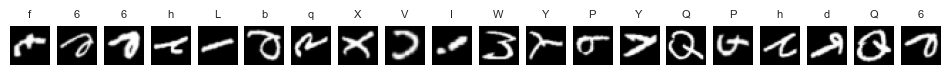

In [6]:
def show_image_of_data(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_image_of_data(train_loader, n=20)

In [7]:
class MLP(nn.Module):
    def __init__(
            self,
            input_size: int = 28 * 28,
            hidden_dims: tuple = (512, 256),
            class_nums: int = 47,
            activation: str = "relu",
            dropout_p: float = 0.0,
            use_batch_norm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknow activation function: {act}")

        layers = [nn.Flatten()]

        prev = input_size
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer(h))
            if dropout_p != 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, class_nums))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Fast check it up
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
with torch.no_grad():
    out = model(x_batch.to(device)).to(device)
    loss = criterion(out, y_batch.to(device)).to(device)
print("Loss function value: ", loss)
print("Logits model out: ", out.shape)

Loss function value:  tensor(3.8617, device='cuda:0')
Logits model out:  torch.Size([256, 47])


In [8]:
def train_one_epoch(
        model: nn.Module,
        loader: DataLoader,
        optimizer: optim.Optimizer,
        criterion: nn.Module,
        device,
):
    batch_count = 0
    total_acc = 0
    total_loss = 0

    model.train()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        optimizer.step()

        total_acc += accuracy_from_logits(logits, y)
        total_loss += loss.item()
        batch_count += 1

    return total_loss / batch_count, total_acc / batch_count


@torch.no_grad()
def evaluate(
        model: nn.Module,
        loader: DataLoader,
        criterion: nn.Module,
        device,
):
    model.eval()

    batch_count = 0
    total_acc = 0
    total_loss = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_acc += accuracy_from_logits(logits, y)
        total_loss += loss.item()
        batch_count += 1

    return total_loss / batch_count, total_acc / batch_count

In [9]:
class EarlyStopping:
    def __init__(
        self,
        patience: int = 10,
        min_delta: float = 0.05,
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.best_state = None
        self.total_epochs = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.counter = 0
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        self.counter += 1
        self.total_epochs += 1
        return self.counter >= self.patience

    def restore_model(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [10]:
def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device,
    epochs: int = 20,
    early_stopping: EarlyStopping = None,
    verbose: bool = True,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(
                f"epoch: {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f}, acc={val_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"Early stopping\nThe best accuracy is {early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_model(model)
                break

    return history

epoch: 01/20 | train_loss=1.3222, acc=0.6190 | val_loss=0.7991, acc=0.7537
epoch: 02/20 | train_loss=0.6909, acc=0.7795 | val_loss=0.6519, acc=0.7956
epoch: 03/20 | train_loss=0.5641, acc=0.8121 | val_loss=0.5519, acc=0.8227
epoch: 04/20 | train_loss=0.4943, acc=0.8320 | val_loss=0.5199, acc=0.8247
epoch: 05/20 | train_loss=0.4492, acc=0.8444 | val_loss=0.4948, acc=0.8318
epoch: 06/20 | train_loss=0.4132, acc=0.8551 | val_loss=0.4785, acc=0.8380
epoch: 07/20 | train_loss=0.3877, acc=0.8616 | val_loss=0.4685, acc=0.8485
epoch: 08/20 | train_loss=0.3653, acc=0.8675 | val_loss=0.4656, acc=0.8473
epoch: 09/20 | train_loss=0.3459, acc=0.8715 | val_loss=0.4727, acc=0.8424
epoch: 10/20 | train_loss=0.3284, acc=0.8781 | val_loss=0.4654, acc=0.8466
epoch: 11/20 | train_loss=0.3149, acc=0.8811 | val_loss=0.4651, acc=0.8478
epoch: 12/20 | train_loss=0.2976, acc=0.8865 | val_loss=0.4670, acc=0.8500
epoch: 13/20 | train_loss=0.2855, acc=0.8901 | val_loss=0.4616, acc=0.8505
epoch: 14/20 | train_loss

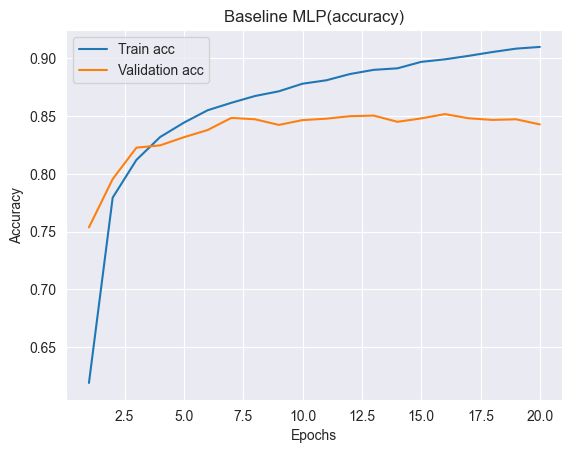

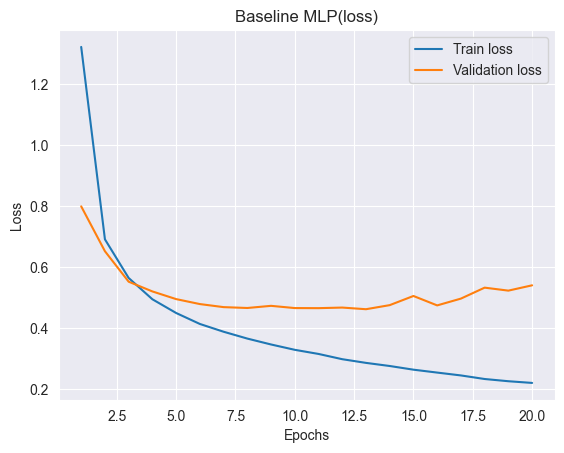

In [11]:
# Baseline:

set_seed(42)
baseline = MLP(hidden_dims=(512, 256, 128), dropout_p=0.0).to(device)

criterion_baseline = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline,
    train_loader,
    val_loader,
    optimizer=optimizer_baseline,
    criterion=criterion_baseline,
    device=device,
)

add_to_csv(
    RUNS,
    "E1",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU",
    "Adam",
    lr=1e-3,
    best_val_accuracy=max(history_baseline["val_acc"]),
    best_val_loss=min(history_baseline["val_loss"])
)

plot_history(history_baseline, title="Baseline MLP")

epoch: 01/20 | train_loss=1.9249, acc=0.4502 | val_loss=0.9512, acc=0.7111
epoch: 02/20 | train_loss=1.1562, acc=0.6480 | val_loss=0.7648, acc=0.7596
epoch: 03/20 | train_loss=0.9987, acc=0.6915 | val_loss=0.6605, acc=0.7921
epoch: 04/20 | train_loss=0.9179, acc=0.7134 | val_loss=0.6272, acc=0.7981
epoch: 05/20 | train_loss=0.8732, acc=0.7263 | val_loss=0.5985, acc=0.8102
epoch: 06/20 | train_loss=0.8313, acc=0.7378 | val_loss=0.5793, acc=0.8157
epoch: 07/20 | train_loss=0.8089, acc=0.7440 | val_loss=0.5579, acc=0.8169
epoch: 08/20 | train_loss=0.7811, acc=0.7506 | val_loss=0.5404, acc=0.8199
epoch: 09/20 | train_loss=0.7674, acc=0.7547 | val_loss=0.5321, acc=0.8295
epoch: 10/20 | train_loss=0.7512, acc=0.7610 | val_loss=0.5310, acc=0.8240
epoch: 11/20 | train_loss=0.7437, acc=0.7628 | val_loss=0.5129, acc=0.8296
epoch: 12/20 | train_loss=0.7293, acc=0.7658 | val_loss=0.5154, acc=0.8309
epoch: 13/20 | train_loss=0.7189, acc=0.7692 | val_loss=0.5108, acc=0.8313
epoch: 14/20 | train_loss

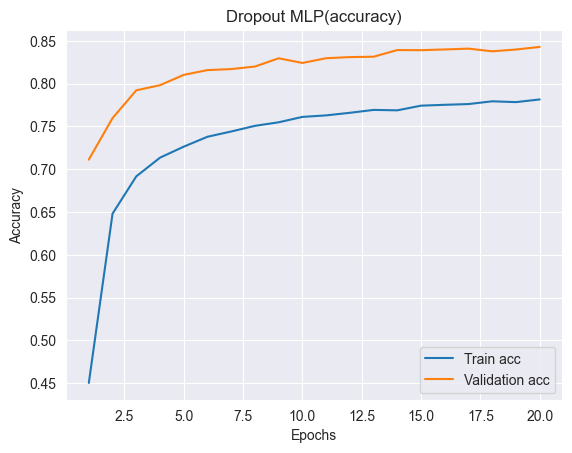

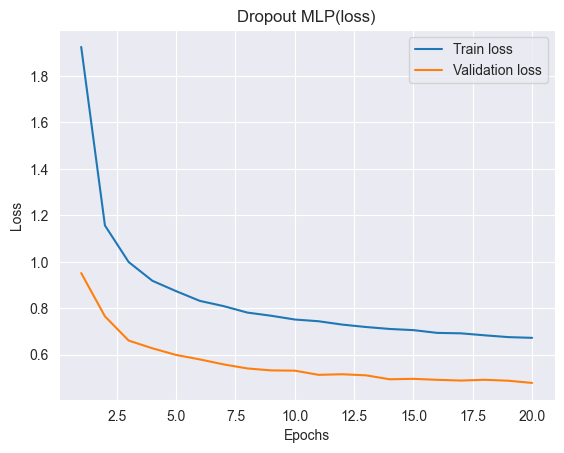

In [12]:
# E2 Dropout => p = 0.4

dropout_MLP = MLP(hidden_dims=(512, 256, 128), dropout_p=0.4).to(device)

criterion_dropout = nn.CrossEntropyLoss()
optimizer_dropout = optim.Adam(dropout_MLP.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_MLP,
    train_loader,
    val_loader,
    optimizer=optimizer_dropout,
    criterion=criterion_dropout,
    device=device,
    epochs=20,
)

add_to_csv(
    RUNS,
    "E2",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU dropout_p=0.4",
    "Adam",
    lr=1e-3,
    best_val_accuracy=max(history_dropout["val_acc"]),
    best_val_loss=min(history_dropout["val_loss"])
)

plot_history(history_dropout, title="Dropout MLP")

epoch: 01/20 | train_loss=0.9610, acc=0.7442 | val_loss=0.5593, acc=0.8224
epoch: 02/20 | train_loss=0.4778, acc=0.8392 | val_loss=0.4814, acc=0.8397
epoch: 03/20 | train_loss=0.3965, acc=0.8596 | val_loss=0.4452, acc=0.8496
epoch: 04/20 | train_loss=0.3462, acc=0.8746 | val_loss=0.4498, acc=0.8469
epoch: 05/20 | train_loss=0.3144, acc=0.8839 | val_loss=0.4402, acc=0.8528
epoch: 06/20 | train_loss=0.2874, acc=0.8919 | val_loss=0.4406, acc=0.8530
epoch: 07/20 | train_loss=0.2631, acc=0.8989 | val_loss=0.4291, acc=0.8583
epoch: 08/20 | train_loss=0.2445, acc=0.9046 | val_loss=0.4288, acc=0.8565
epoch: 09/20 | train_loss=0.2289, acc=0.9094 | val_loss=0.4640, acc=0.8514
epoch: 10/20 | train_loss=0.2130, acc=0.9153 | val_loss=0.4691, acc=0.8512
epoch: 11/20 | train_loss=0.2029, acc=0.9183 | val_loss=0.4775, acc=0.8517
epoch: 12/20 | train_loss=0.1912, acc=0.9222 | val_loss=0.4835, acc=0.8486
epoch: 13/20 | train_loss=0.1806, acc=0.9262 | val_loss=0.4960, acc=0.8455
epoch: 14/20 | train_loss

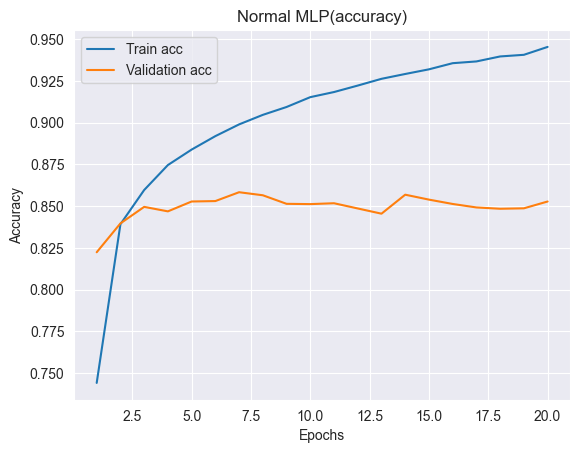

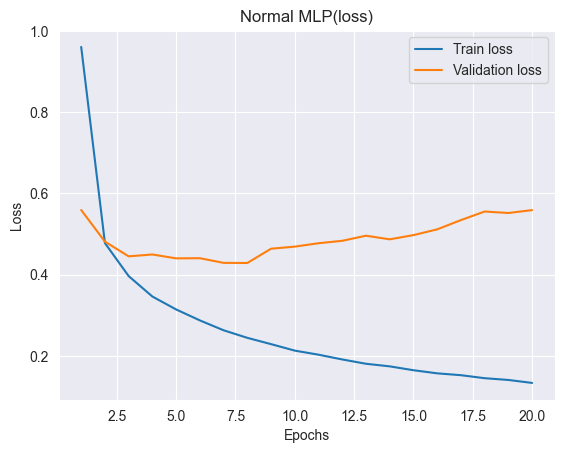

In [13]:
# E3 BatchNorm

Batch_norm_MLP = MLP(hidden_dims=(512, 256, 128), use_batch_norm=True).to(device)
criterion_norm = nn.CrossEntropyLoss()
optimizer_norm = optim.Adam(Batch_norm_MLP.parameters(), lr=1e-3)
history_norm = fit(
    Batch_norm_MLP,
    train_loader,
    val_loader,
    optimizer=optimizer_norm,
    criterion=criterion_norm,
    device=device,
    epochs=20,
)

add_to_csv(
    RUNS,
    "E3",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU BN",
    "Adam",
    lr=1e-3,
    best_val_accuracy=max(history_norm["val_acc"]),
    best_val_loss=min(history_norm["val_loss"])
)

plot_history(history_norm, title="Normal MLP")

epoch: 01/100 | train_loss=0.9484, acc=0.7479 | val_loss=0.5743, acc=0.8260
epoch: 02/100 | train_loss=0.4741, acc=0.8402 | val_loss=0.4823, acc=0.8450
epoch: 03/100 | train_loss=0.3919, acc=0.8622 | val_loss=0.4378, acc=0.8544
epoch: 04/100 | train_loss=0.3433, acc=0.8761 | val_loss=0.4407, acc=0.8501
epoch: 05/100 | train_loss=0.3140, acc=0.8849 | val_loss=0.4369, acc=0.8546
epoch: 06/100 | train_loss=0.2846, acc=0.8921 | val_loss=0.4333, acc=0.8571
epoch: 07/100 | train_loss=0.2631, acc=0.8985 | val_loss=0.4271, acc=0.8616
epoch: 08/100 | train_loss=0.2433, acc=0.9048 | val_loss=0.4297, acc=0.8595
epoch: 09/100 | train_loss=0.2262, acc=0.9107 | val_loss=0.4444, acc=0.8604
epoch: 10/100 | train_loss=0.2123, acc=0.9148 | val_loss=0.4598, acc=0.8514
epoch: 11/100 | train_loss=0.2043, acc=0.9169 | val_loss=0.4530, acc=0.8600
epoch: 12/100 | train_loss=0.1891, acc=0.9235 | val_loss=0.4603, acc=0.8573
Early stopping
The best accuracy is 0.8616


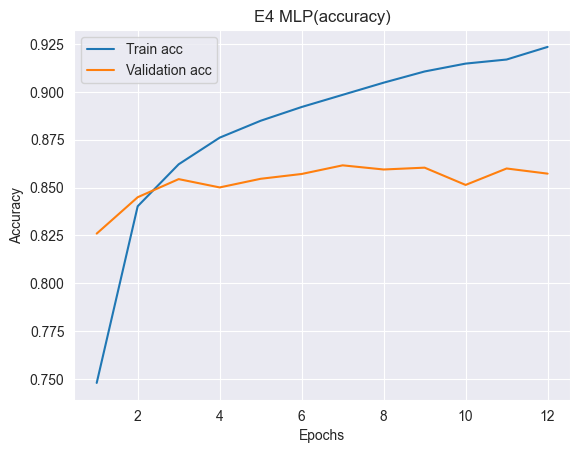

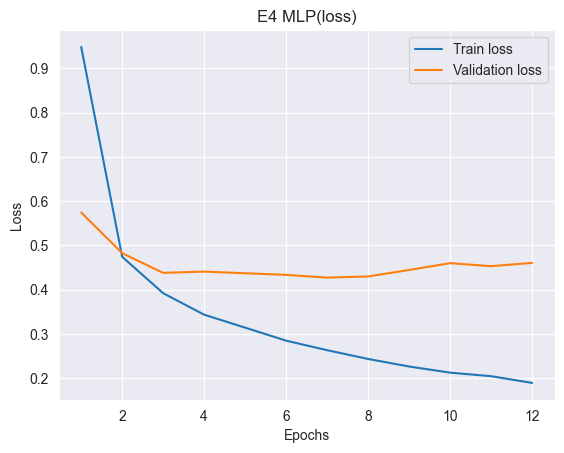

In [14]:
# We choose the E3 model for E4 experiment because the model with batch normalization has the best validation accuracy
# E4

early_stopping = EarlyStopping(patience=5, min_delta=0.003)

E4_model = MLP(hidden_dims=(512, 256, 128), use_batch_norm=True).to(device)
criterion_e4 = nn.CrossEntropyLoss()
optimizer_e4 = optim.Adam(E4_model.parameters(), lr=1e-3)
history_e4 = fit(
    E4_model,
    train_loader,
    val_loader,
    optimizer=optimizer_e4,
    criterion=criterion_e4,
    device=device,
    epochs=100,
    early_stopping=early_stopping,
)

add_to_csv(
    RUNS,
    "E4",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU BN Early_Stopping",
    "Adam",
    lr=1e-3,
    epochs_trained=early_stopping.total_epochs,
    best_val_accuracy=max(history_e4["val_acc"]),
    best_val_loss=min(history_e4["val_loss"])
)

plot_history(history_e4, title="E4 MLP", save_name="curves_best")

In [15]:
test_loss, test_acc = evaluate(E4_model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

Test loss: 0.4526, test accuracy: 0.8514


In [16]:
torch.save(E4_model.state_dict(), "artifacts/best_model.pt")

In [17]:
import json

def save_to_json(
        path: str,
        dataset: str,
        seed: int,
        input_size: int,
        hidden_size: tuple,
        activation: str,
        class_num: int,
        dropout_p: float,
        batch_norm: bool,
        optimizer_name: str,
        lr: float,
        weight_decay: float,
        epochs: int,
        early_stopping_patience: int,
):
    os.makedirs(path, exist_ok=True)

    config = {
        "dataset": dataset,
        "seed": seed,
        "model": {
            "input_size": input_size,
            "hidden_dims": hidden_size,
            "activation": activation,
            "dropout_p": dropout_p,
            "batch_norm": batch_norm,
            "class_num": class_num,
        },
        "optimizer": {
            "name": optimizer_name,
            "lr": lr,
            "weight_decay": weight_decay
        },
        "training": {
            "epochs": epochs,
            "early_stopping_patience": early_stopping_patience,
        }
    }

    with open(path + "/best_config.json", "w") as f:
        json.dump(config, f, indent=4)

save_to_json(
    path="./artifacts",
    dataset="EMNIST",
    seed=42,
    input_size=28*28,
    hidden_size=(512, 256, 128),
    activation="relu",
    class_num=47,
    dropout_p=0.0,
    batch_norm=True,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=early_stopping.total_epochs,
    early_stopping_patience=5,
)

epoch: 01/8 | train_loss=0.9925, acc=0.6926 | val_loss=0.8125, acc=0.7478
epoch: 02/8 | train_loss=0.6557, acc=0.7835 | val_loss=0.6643, acc=0.7891
epoch: 03/8 | train_loss=0.5782, acc=0.8061 | val_loss=0.5908, acc=0.8085
epoch: 04/8 | train_loss=0.5292, acc=0.8197 | val_loss=0.6179, acc=0.8038
epoch: 05/8 | train_loss=0.4966, acc=0.8300 | val_loss=0.5543, acc=0.8220
epoch: 06/8 | train_loss=0.4662, acc=0.8383 | val_loss=0.5679, acc=0.8176
epoch: 07/8 | train_loss=0.4421, acc=0.8460 | val_loss=0.5254, acc=0.8385
epoch: 08/8 | train_loss=0.4307, acc=0.8469 | val_loss=0.5976, acc=0.8232


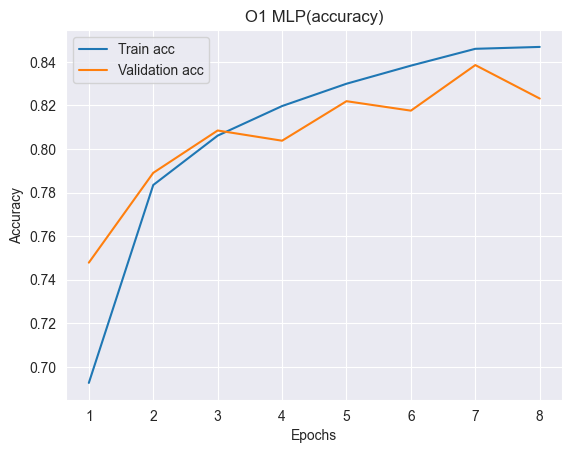

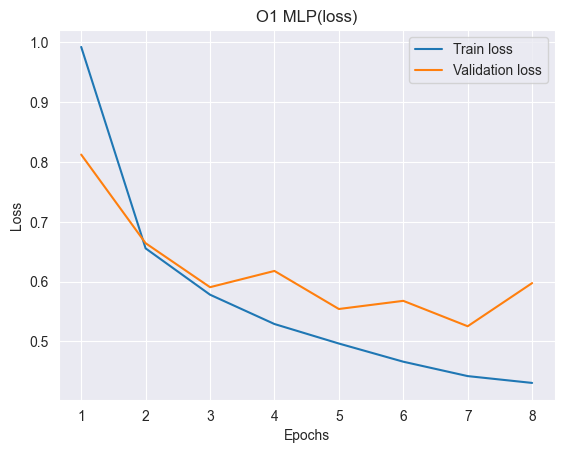

In [18]:
model_O1 = MLP(
    hidden_dims=(512, 256, 128),
    use_batch_norm=True,
    dropout_p=0.0,
).to(device)

optimizer_O1 = optim.Adam(model_O1.parameters(), lr=1e-1)
criterion_O1 = nn.CrossEntropyLoss()

O1_history = fit(
    model_O1,
    train_loader,
    val_loader,
    optimizer=optimizer_O1,
    criterion=criterion_O1,
    device=device,
    epochs=8,
)

add_to_csv(
    RUNS,
    "O1",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU BN",
    "Adam",
    lr=1e-1,
    epochs_trained=8,
    best_val_accuracy=max(O1_history["val_acc"]),
    best_val_loss=min(O1_history["val_loss"])
)

plot_history(O1_history, title="O1 MLP")

epoch: 01/6 | train_loss=3.4645, acc=0.1911 | val_loss=3.1076, acc=0.3712
epoch: 02/6 | train_loss=2.8964, acc=0.4562 | val_loss=2.7120, acc=0.5138
epoch: 03/6 | train_loss=2.5649, acc=0.5558 | val_loss=2.4381, acc=0.5833
epoch: 04/6 | train_loss=2.3165, acc=0.6056 | val_loss=2.2193, acc=0.6188
epoch: 05/6 | train_loss=2.1131, acc=0.6405 | val_loss=2.0299, acc=0.6453
epoch: 06/6 | train_loss=1.9397, acc=0.6663 | val_loss=1.8693, acc=0.6689


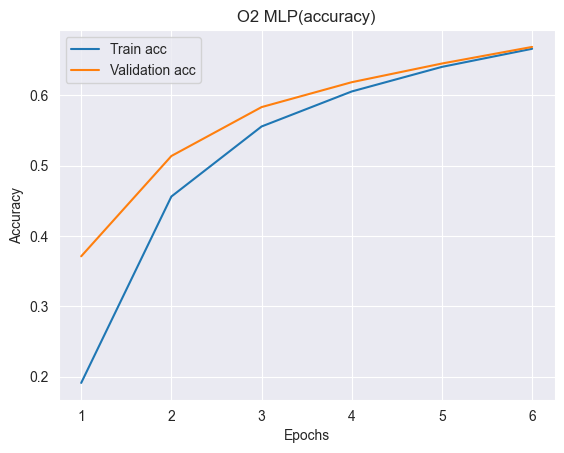

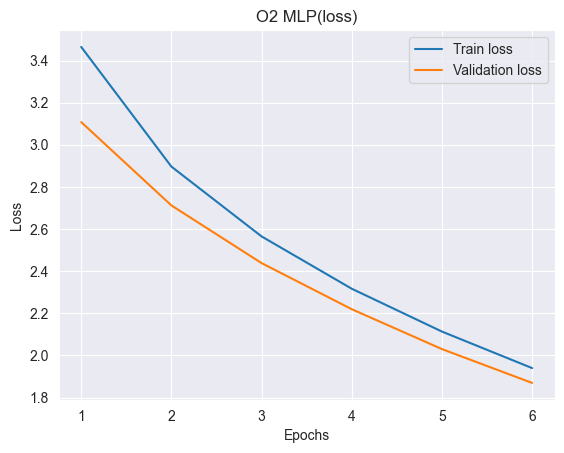

In [19]:
model_O2 = MLP(
    hidden_dims=(512, 256, 128),
    use_batch_norm=True,
).to(device)

optimizer_O2 = optim.Adam(params=model_O2.parameters(), lr=1e-5)
criterion_O2 = nn.CrossEntropyLoss()
O2_history = fit(
    model_O2,
    train_loader,
    val_loader,
    optimizer=optimizer_O2,
    criterion=criterion_O2,
    device=device,
    epochs=6,
)

add_to_csv(
    RUNS,
    "O2",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU BN",
    "Adam",
    lr=1e-5,
    epochs_trained=6,
    best_val_accuracy=max(O2_history["val_acc"]),
    best_val_loss=min(O2_history["val_loss"])
)

plot_history(O2_history, title="O2 MLP")

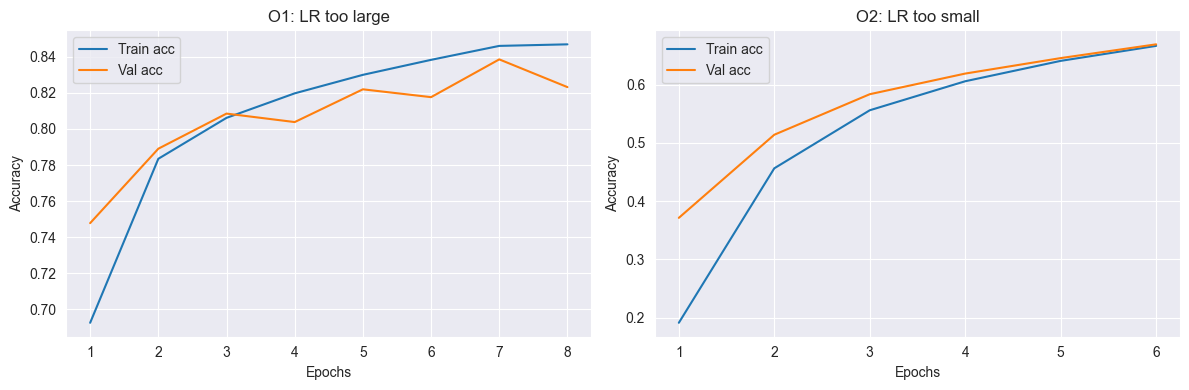

In [20]:
plot_lr_extremes(
    O1_history,
    O2_history,
    save_path="./artifacts/figures/curves_lr_extremes.png"
)

epoch: 01/12 | train_loss=2.6907, acc=0.4448 | val_loss=1.9572, acc=0.6116
epoch: 02/12 | train_loss=1.5914, acc=0.6616 | val_loss=1.3071, acc=0.6998
epoch: 03/12 | train_loss=1.1352, acc=0.7283 | val_loss=1.0068, acc=0.7522
epoch: 04/12 | train_loss=0.9049, acc=0.7662 | val_loss=0.8390, acc=0.7792
epoch: 05/12 | train_loss=0.7677, acc=0.7916 | val_loss=0.7409, acc=0.7967
epoch: 06/12 | train_loss=0.6771, acc=0.8116 | val_loss=0.6743, acc=0.8095
epoch: 07/12 | train_loss=0.6105, acc=0.8239 | val_loss=0.6247, acc=0.8194
epoch: 08/12 | train_loss=0.5606, acc=0.8365 | val_loss=0.5917, acc=0.8254
epoch: 09/12 | train_loss=0.5201, acc=0.8451 | val_loss=0.5639, acc=0.8316
epoch: 10/12 | train_loss=0.4869, acc=0.8535 | val_loss=0.5420, acc=0.8356
epoch: 11/12 | train_loss=0.4588, acc=0.8602 | val_loss=0.5271, acc=0.8413
epoch: 12/12 | train_loss=0.4337, acc=0.8673 | val_loss=0.5144, acc=0.8425


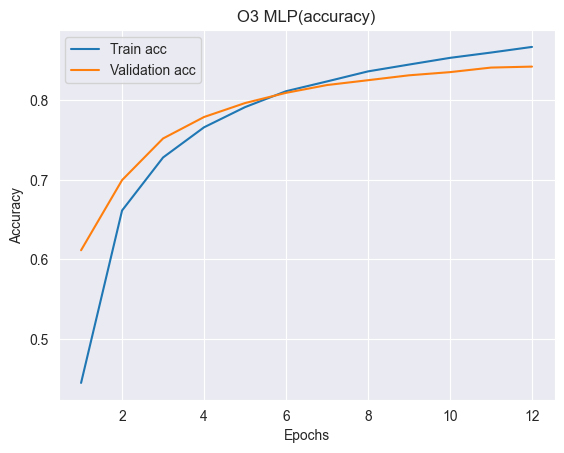

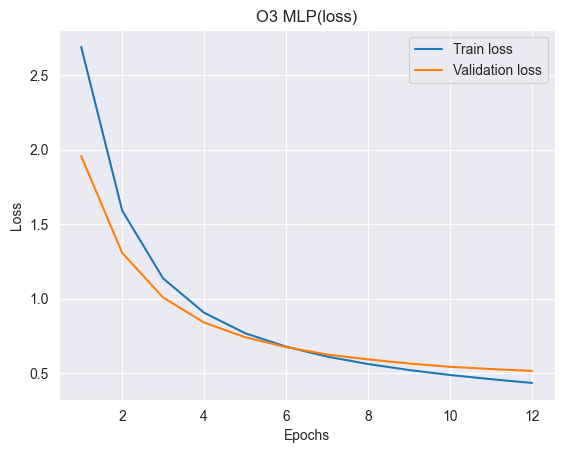

In [21]:
model_O3 = MLP(
    hidden_dims=(512, 256, 128),
    use_batch_norm=True,
).to(device)

optimizer_O3 = optim.SGD(params=model_O3.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
criterion_O3 = nn.CrossEntropyLoss()
O3_history = fit(
    model_O3,
    train_loader,
    val_loader,
    optimizer=optimizer_O3,
    criterion=criterion_O3,
    device=device,
    epochs=12,
)

add_to_csv(
    RUNS,
    "O3",
    "EMNIST",
    SEED,
    "(512, 256, 128) ReLU BN",
    "SGD",
    lr=1e-3,
    weight_decay=1e-4,
    momentum=0.9,
    epochs_trained=12,
    best_val_accuracy=max(O3_history["val_acc"]),
    best_val_loss=min(O3_history["val_loss"])
)

plot_history(
    O3_history,
    title="O3 MLP",
)

In [22]:
save_csv(RUNS, "./artifacts/runs.csv")

# This is optional part of homework
Here we should compare the tho others optimizer for one model (256, 128) with BN

epoch: 01/15 | train_loss=1.0867, acc=0.7202 | val_loss=0.6414, acc=0.7977
epoch: 02/15 | train_loss=0.5326, acc=0.8285 | val_loss=0.5136, acc=0.8339
epoch: 03/15 | train_loss=0.4432, acc=0.8507 | val_loss=0.4815, acc=0.8402
epoch: 04/15 | train_loss=0.3957, acc=0.8636 | val_loss=0.4668, acc=0.8469
epoch: 05/15 | train_loss=0.3615, acc=0.8722 | val_loss=0.4474, acc=0.8483
epoch: 06/15 | train_loss=0.3351, acc=0.8798 | val_loss=0.4511, acc=0.8462
epoch: 07/15 | train_loss=0.3145, acc=0.8854 | val_loss=0.4394, acc=0.8529
epoch: 08/15 | train_loss=0.2940, acc=0.8914 | val_loss=0.4498, acc=0.8512
epoch: 09/15 | train_loss=0.2789, acc=0.8965 | val_loss=0.4486, acc=0.8524
epoch: 10/15 | train_loss=0.2664, acc=0.9001 | val_loss=0.4599, acc=0.8503
epoch: 11/15 | train_loss=0.2540, acc=0.9035 | val_loss=0.4654, acc=0.8482
epoch: 12/15 | train_loss=0.2424, acc=0.9074 | val_loss=0.4662, acc=0.8494
epoch: 13/15 | train_loss=0.2319, acc=0.9103 | val_loss=0.4849, acc=0.8462
epoch: 14/15 | train_loss

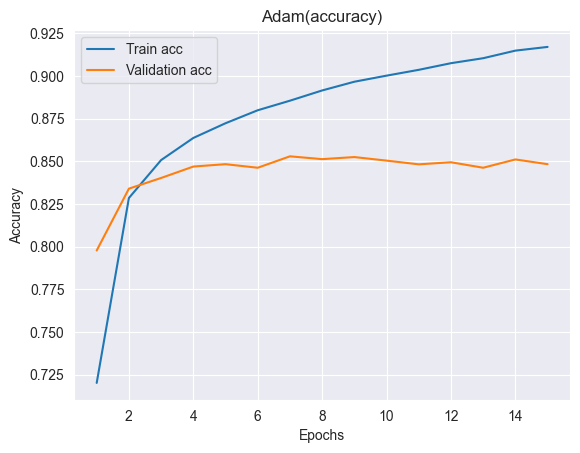

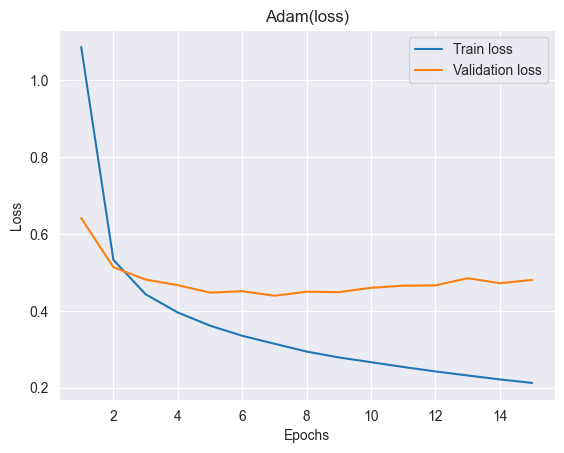

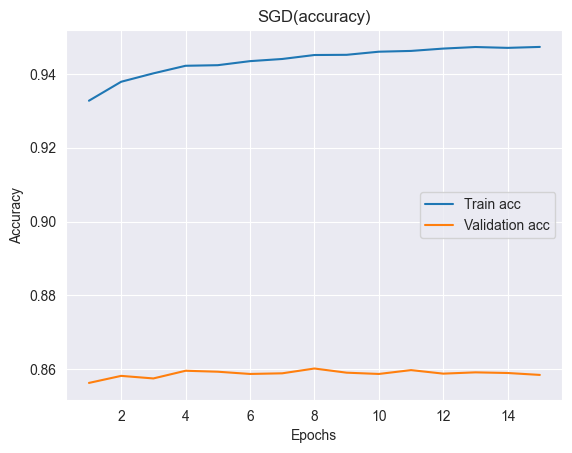

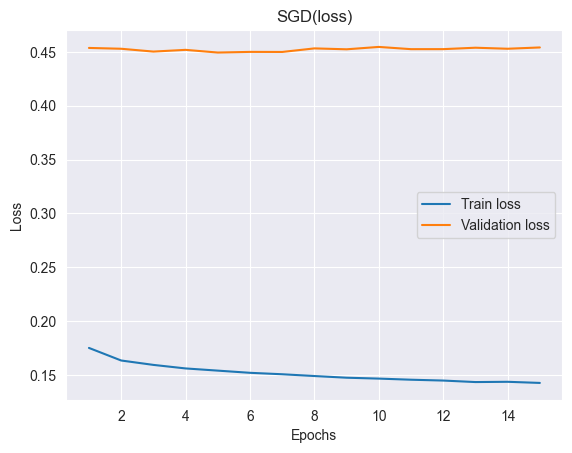

In [23]:
opt_model = MLP(
    input_size=28*28,
    hidden_dims=(256, 128),
    use_batch_norm=True,
).to(device)

optimizer_adam = optim.Adam(params=opt_model.parameters(), lr=1e-3)
optimizer_SGD = optim.SGD(params=opt_model.parameters(), lr=1e-3, momentum=0.9)

criterion = nn.CrossEntropyLoss()

history_adam = fit(
    opt_model,
    train_loader,
    val_loader,
    optimizer=optimizer_adam,
    criterion=criterion,
    device=device,
    epochs=15,
)

history_SGD = fit(
    opt_model,
    train_loader,
    val_loader,
    optimizer=optimizer_SGD,
    criterion=criterion,
    device=device,
    epochs=15,
)

plot_history(history_adam, title="Adam")
plot_history(history_SGD, title="SGD")

On the figures We can see that SGD win than Adam with lr=1e-3 and momentum=0.9 without other settings

This can show that SGD work better than Adam out the box

## Two other seeds for comparing

now, I compared the seeds 42 and 30, after it, I get the result, which show different seeds do not change the result absolutely

In [24]:
print(SEED)
set_seed(30)

42


## Here we need to compute the confusion matrix of best model for test part of data

In [25]:
@torch.no_grad()
def compute_the_confusion_matrix(
        model: nn.Module,
        loader: DataLoader,
        device: device,
):
    model.eval()
    
    all_preds = []
    all_targets = []
    
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        y_pred = torch.argmax(logits, dim=1)
        
        all_preds.append(y_pred.cpu())
        all_targets.append(y.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    cm = confusion_matrix(all_targets, all_preds)
    return cm

confusion_matrix = compute_the_confusion_matrix(E4_model, test_loader, device)

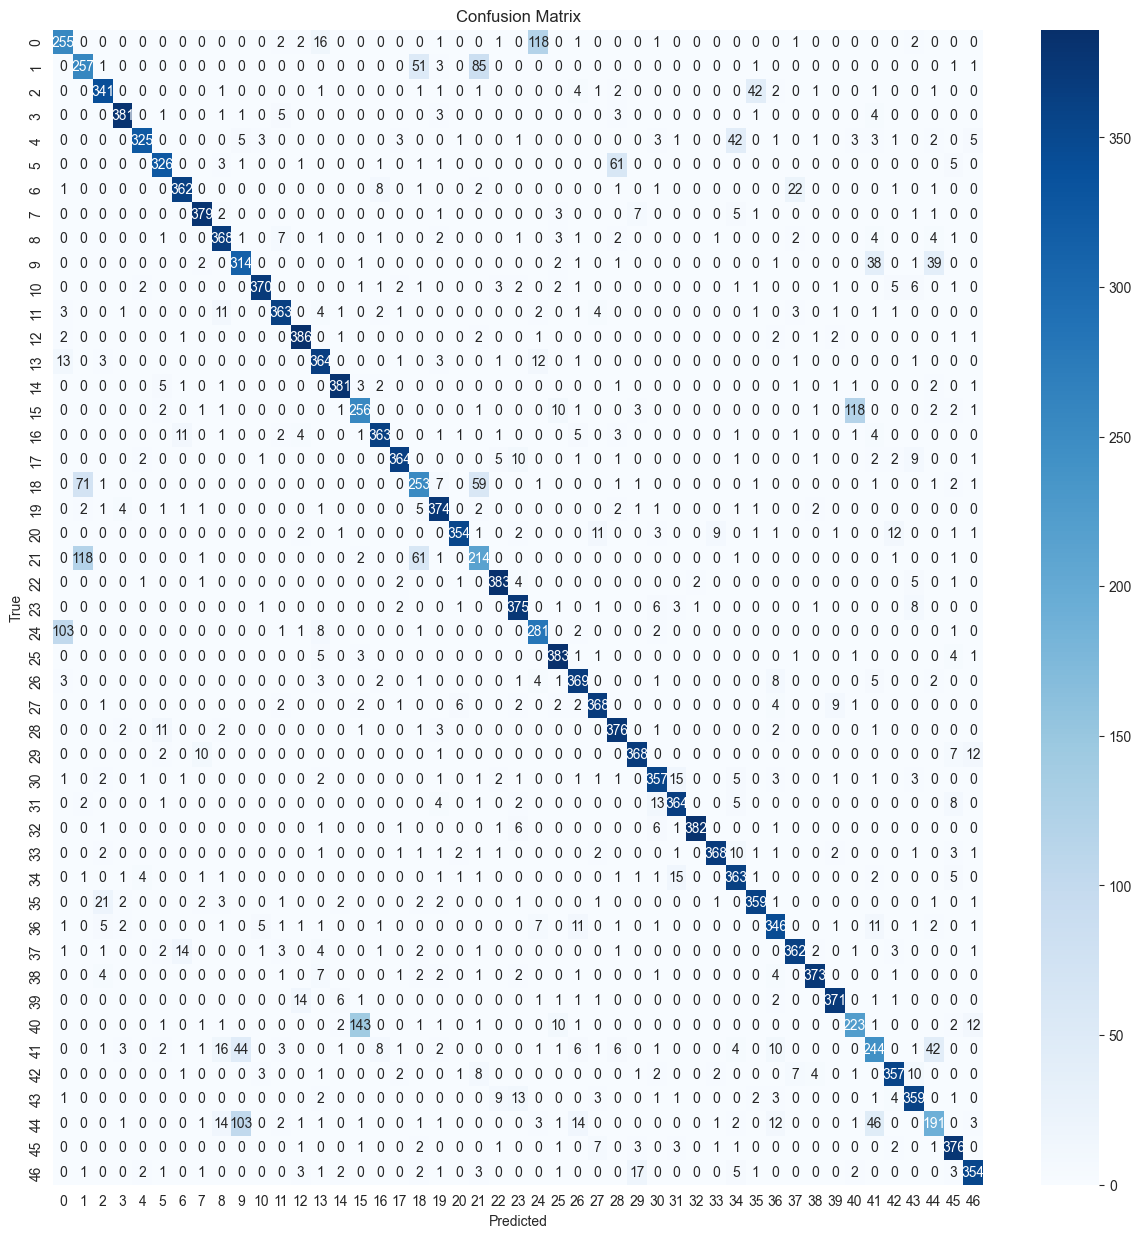

In [26]:
plt.figure(figsize=(15, 15))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("./artifacts/figures/confusion_matrix_of_best_model.png")
plt.show()